In [3]:
# prompt: write down the code for to import the data file in colab

from google.colab import files
uploaded = files.upload()


Saving sales.csv to sales.csv


In [4]:
import pandas as pd
df = pd.read_csv("sales.csv")
df.head()


,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,1,138,73,11,276,120,Bad,42,17,Yes,Yes,yes
1,2,111,48,16,260,83,Good,65,10,Yes,Yes,yes
2,3,113,35,10,269,80,Medium,59,12,Yes,Yes,yes
3,4,117,100,4,466,97,Medium,55,14,Yes,Yes,no
4,5,141,64,3,340,128,Bad,38,13,Yes,No,no


In [5]:
# prompt: identify the object variable from above df and apply label encode in them

from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
le = LabelEncoder()

# Iterate over the columns of the DataFrame
for col in df.columns:
    # Check if the column is an object variable
    if df[col].dtype == 'object':
        # Apply label encoding to the column
        df[col] = le.fit_transform(df[col])


In [ ]:
df.head()

,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,1,138,73,11,276,120,0,42,17,1,1,1
1,2,111,48,16,260,83,1,65,10,1,1,1
2,3,113,35,10,269,80,2,59,12,1,1,1
3,4,117,100,4,466,97,2,55,14,1,1,0
4,5,141,64,3,340,128,0,38,13,1,0,0


In [6]:
Y = df["high"]
X = df.iloc[:,1:11]
X.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,138,73,11,276,120,0,42,17,1,1
1,111,48,16,260,83,1,65,10,1,1
2,113,35,10,269,80,2,59,12,1,1
3,117,100,4,466,97,2,55,14,1,1
4,141,64,3,340,128,0,38,13,1,0


In [7]:
# prompt: divide the data in training and test, fit the model using decision tree for training samples, calculate the training and testing accuracies

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Fit the model using Decision Tree for training samples
model = DecisionTreeClassifier(criterion='gini')
model.fit(X_train, y_train)

# Calculate the training and testing accuracies
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

# Print the training and testing accuracies
print("Training accuracy:", train_acc)
print("Testing accuracy:", test_acc)


Training accuracy: 1.0
Testing accuracy: 0.725


In [ ]:
# prompt: divide the data in training and test, fit the model using decision tree for training samples, calculate the training and testing accuracies

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Fit the model using Decision Tree for training samples
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)

# Calculate the training and testing accuracies
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

# Print the training and testing accuracies
print("Training accuracy:", train_acc)
print("Testing accuracy:", test_acc)


Training accuracy: 1.0
Testing accuracy: 0.75


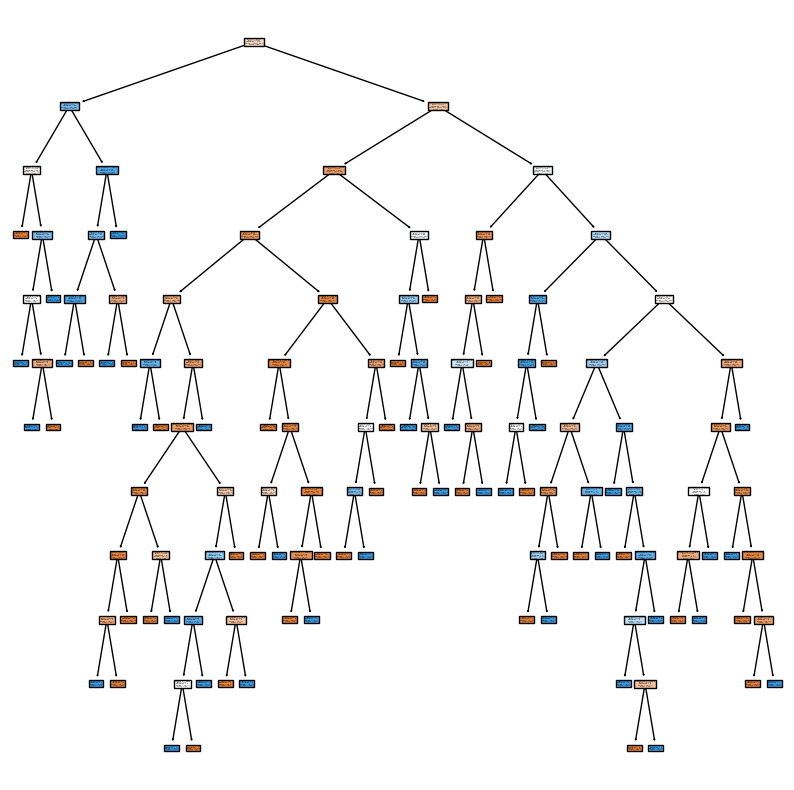

In [ ]:
# prompt: draw the graph of decision tree from the above

from sklearn import tree
import matplotlib.pyplot as plt

# Create a DecisionTreeClassifier object
clf = DecisionTreeClassifier()

# Fit the model to the training data
clf.fit(X, Y)

# Create a figure and axes object
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the decision tree
tree.plot_tree(clf, ax=ax, feature_names=X.columns, class_names=["No", "Yes"], filled=True)

# Display the plot
plt.show()


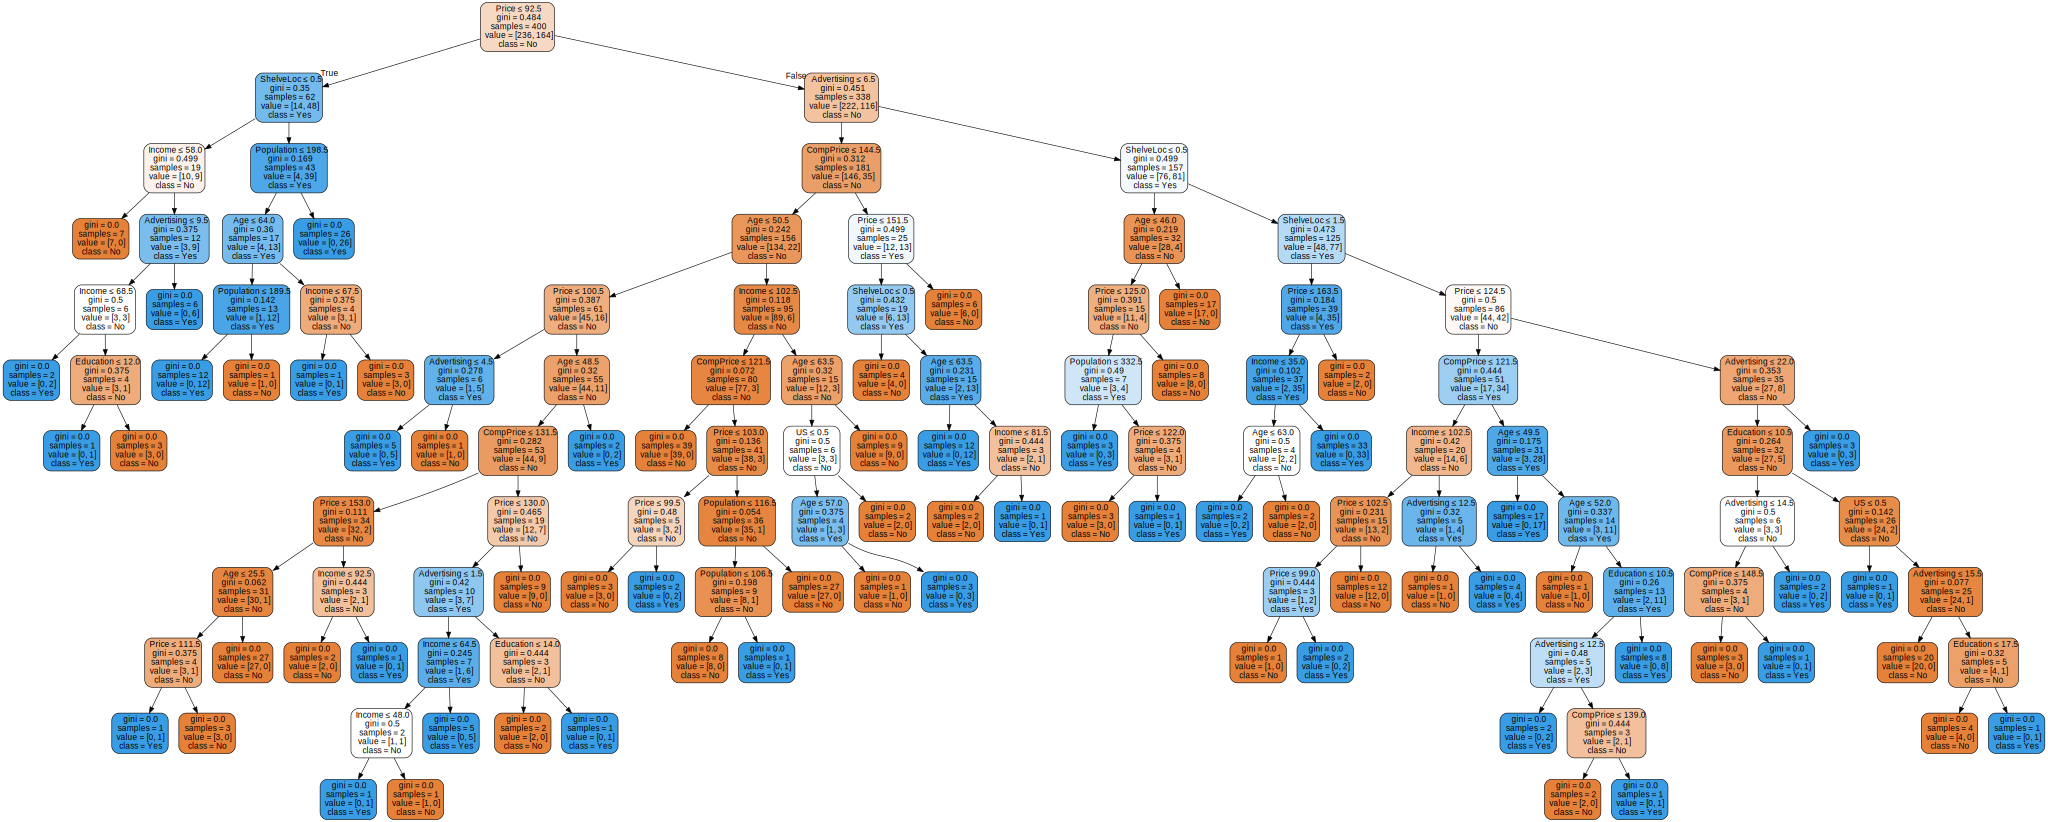

In [ ]:
# prompt: use the graphviz package and visualize the decision tree graph

import graphviz
dot_data = tree.export_graphviz(clf, out_file=None,
                         feature_names=X.columns,
                         class_names=["No", "Yes"],
                         filled=True, rounded=True,
                         special_characters=True)
graph = graphviz.Source(dot_data)
graph


In [ ]:
# prompt: count the number of nodes and depth of the above decision tree

# Get the number of nodes in the tree
num_nodes = model.tree_.node_count

# Get the depth of the tree
max_depth = model.tree_.max_depth

# Print the number of nodes and depth of the tree
print("Number of nodes:", num_nodes)
print("Depth of the tree:", max_depth)


Number of nodes: 101
Depth of the tree: 14


In [ ]:
# prompt: divide the data in training and test, fit the model using decision tree for training samples, calculate the training and testing accuracies

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Fit the model using Decision Tree for training samples
model = DecisionTreeClassifier(criterion='gini',max_depth=7)
model.fit(X_train, y_train)

# Calculate the training and testing accuracies
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

# Print the training and testing accuracies
print("Training accuracy:", train_acc)
print("Testing accuracy:", test_acc)


Training accuracy: 0.925
Testing accuracy: 0.775


In [ ]:
# prompt: count the number of nodes and depth of the above decision tree

# Get the number of nodes in the tree
num_nodes = model.tree_.node_count

# Get the depth of the tree
max_depth = model.tree_.max_depth

# Print the number of nodes and depth of the tree
print("Number of nodes:", num_nodes)
print("Depth of the tree:", max_depth)


Number of nodes: 77
Depth of the tree: 7


In [ ]:
# prompt: write down the code for bagging classifier and fit the model and calculate the traiining and testing accuracies

from sklearn.ensemble import BaggingClassifier

# Create a BaggingClassifier object
bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=7), n_estimators=100, max_features=0.7,max_samples=0.6)

# Fit the model to the training data
bag_clf.fit(X_train, y_train)

# Calculate the training and testing accuracies
train_acc = accuracy_score(y_train, bag_clf.predict(X_train))
test_acc = accuracy_score(y_test, bag_clf.predict(X_test))

# Print the training and testing accuracies
print("Training accuracy:", train_acc)
print("Testing accuracy:", test_acc)


Training accuracy: 0.996875
Testing accuracy: 0.8


In [ ]:
train_acc=[]
test_acc = []

In [ ]:
for i in range(1,101,1):
  bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=7), n_estimators=100, max_features=0.7,max_samples=0.6,random_state=i)
  bag_clf.fit(X_train, y_train)
  train_acc.append(accuracy_score(y_train, bag_clf.predict(X_train)))
  test_acc.append(accuracy_score(y_test, bag_clf.predict(X_test)))


In [ ]:
import numpy as np
print("Bagging classifier-Cross validation training accuracy",np.mean(train_acc).round(2))
print("Bagging classifier-Cross validation test accuracy",np.mean(test_acc).round(2))

Bagging classifier-Cross validation training accuracy 0.99
Bagging classifier-Cross validation test accuracy 0.79


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create a RandomForestClassifier object
RFC_clf = RandomForestClassifier(n_estimators=100, max_features=0.7,max_samples=0.6,max_depth=10)

# Fit the model to the training data
RFC_clf.fit(X_train, y_train)

# Calculate the training and testing accuracies
train_acc = accuracy_score(y_train, RFC_clf.predict(X_train))
test_acc = accuracy_score(y_test, RFC_clf.predict(X_test))

# Print the training and testing accuracies
print("Training accuracy:", train_acc)
print("Testing accuracy:", test_acc)


Training accuracy: 0.996875
Testing accuracy: 0.8


In [ ]:
train_acc=[]
test_acc = []

In [ ]:
for i in range(1,101,1):
  RFC_clf = RandomForestClassifier(n_estimators=100, max_features=0.7,max_samples=0.6,random_state=i,max_depth=5)
  RFC_clf.fit(X_train, y_train)
  train_acc.append(accuracy_score(y_train, RFC_clf.predict(X_train)))
  test_acc.append(accuracy_score(y_test, RFC_clf.predict(X_test)))

import numpy as np
print("RandomForest classifier-Cross validation training accuracy",np.mean(train_acc).round(2))
print("RandomForest classifier-Cross validation test accuracy",np.mean(test_acc).round(2))


RandomForest classifier-Cross validation training accuracy 0.94
RandomForest classifier-Cross validation test accuracy 0.78


In [9]:
# prompt: apply the gradientboostingclassifier for the above data
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier

# Create a GradientBoostingClassifier object
GBC_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=1, random_state=0)

# Fit the model to the training data
GBC_clf.fit(X_train, y_train)

# Calculate the training and testing accuracies
train_acc = accuracy_score(y_train, GBC_clf.predict(X_train))
test_acc = accuracy_score(y_test, GBC_clf.predict(X_test))

# Print the training and testing accuracies
print("Training accuracy:", train_acc)
print("Testing accuracy:", test_acc)

train_acc=[]
test_acc = []
for i in range(1,101,1):
  GBC_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=1, random_state=i)
  GBC_clf.fit(X_train, y_train)
  train_acc.append(accuracy_score(y_train, GBC_clf.predict(X_train)))
  test_acc.append(accuracy_score(y_test, GBC_clf.predict(X_test)))

print("GradientBoosting classifier-Cross validation training accuracy",np.mean(train_acc).round(2))
print("GradientBoosting classifier-Cross validation test accuracy",np.mean(test_acc).round(2))


Training accuracy: 0.875
Testing accuracy: 0.775
GradientBoosting classifier-Cross validation training accuracy 0.88
GradientBoosting classifier-Cross validation test accuracy 0.78


In [ ]:
# prompt: use grid search cv method and apply some different parameters for each inbuilt parameters for the above GradientBoostingClassifier and give the best resutls

from sklearn.model_selection import GridSearchCV

# Create a GradientBoostingClassifier object
GBC_clf = GradientBoostingClassifier()

# Define the parameter grid
param_grid = {
    'n_estimators': [10, 50, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.3, 0.5, 0.7],
    'max_depth': [1, 3, 5, 7, 9],
    'subsample': [0.4, 0.7, 0.9, 1.0],
    'min_samples_split': [2, 3, 5, 7],
    'min_samples_leaf': [1, 3, 5],
    'max_features': [None, 'sqrt']
}

# Create a GridSearchCV object
grid_search = GridSearchCV(GBC_clf, param_grid, cv=5)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters
print("Best parameters:", grid_search.best_params_)

# Print the best score
print("Best score:", grid_search.best_score_)

# Calculate the training and testing accuracies
train_acc = accuracy_score(y_train, grid_search.predict(X_train))
test_acc = accuracy_score(y_test, grid_search.predict(X_test))

# Print the training and testing accuracies
print("Training accuracy:", train_acc)
print("Testing accuracy:", test_acc)